Lab 1 — Text Processing & Tokenisation

In [1]:
# إعداد بيئة قابلة لإعادة التشغيل / Reproducible setup
import importlib.util
import subprocess
import sys

PINNED = {"transformers": "5.15.1", "tokenizers": "0.22.2", "spacy": "3.8.7"}
missing = [name for name in PINNED if importlib.util.find_spec(name) is None]
if missing:
    packages = [f"{name}=={PINNED[name]}" for name in missing]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

print("Python:", sys.version.split()[0])
print("Environment ready / البيئة جاهزة")

Python: 3.13.15
Environment ready / البيئة جاهزة


جهزنا المكتبات التي نحتاجها وننشئ خمس نصوص غير حقيقه لتجربه وتحتوي على مسافه(مرحبــا\بكم"  ),
 نص عربي عادي(أهلاً وسهلاً بكم في برنامج بيان  ),
  بيانات حساسه مثل الايميل والتلفون واخيرا جمل بللغه الانجليزيه
  (Natural language processing connects text and models.  )وذلك لغرض الاختبار  

In [2]:
import html
import re
import unicodedata
from dataclasses import dataclass
from typing import Iterable

import numpy as np
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.pre_tokenizers import BertPreTokenizer
from tokenizers.processors import TemplateProcessing

SEED = 42
rng = np.random.default_rng(SEED)
samples = [
    "أهلاً وسهلاً بكم في برنامج بيان!",
    "مرحبــاً\u00a0بكم",
    "Contact us at learner@example.org",
    "للتجربة فقط: 0551234567",
    "Natural language processing connects text and models.",
]
print("Synthetic samples:", len(samples))

Synthetic samples: 5


**Unicode** هو معيار يعطي كل حرف او رمز
code poind
لغرض التميز ويسهل تمثيله بشكل موحد بين الانظمه مثلا حرف الالف يعرف من بين الانظمه بكود بوينت
unicode للاف =char': 'أ', 'code_point': 'U+0623',

In [3]:
def inspect_unicode(text: str) -> list[dict[str, str]]:
    return [
        {"char": ch, "code_point": f"U+{ord(ch):04X}", "name": unicodedata.name(ch, "UNKNOWN")}
        for ch in text
    ]

unicode_rows = inspect_unicode("أé")
for row in unicode_rows:
    print(row)
assert unicode_rows[0]["code_point"] == "U+0623"
print("Unicode inspection=PASS")

{'char': 'أ', 'code_point': 'U+0623', 'name': 'ARABIC LETTER ALEF WITH HAMZA ABOVE'}
{'char': 'é', 'code_point': 'U+00E9', 'name': 'LATIN SMALL LETTER E WITH ACUTE'}
Unicode inspection=PASS


mask_pii & TextRecord
raw_text & model_text
لابد ان يكون لدي نسخه اصليه لكي لايتم التعديل عليها وتضيعها  ونسخه مهياءه لدخول للمرحله القادمه
raw text   هي النسخه الاصليه ونحتفظ بها لرجوع لتدقيق واعاده المعالجه مثل مرحــــباه
لكن model text هي نسخه يتم تهيئتها لدخول الى Tokenizer
مثل مرحبا بعد التعديل
mask_pii يعني اخفاء البيانات الحساسه خلف رموز او صور او كلمات تدل عليها
normalization توحيد تمثيل النص عشان تكون الصياغه متكافئه باستخدام NFC او توحيد المسافات

In [4]:
ARABIC_DIACRITICS = re.compile(r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]")
TATWEEL = "\u0640"
WHITESPACE = re.compile(r"\s+")
HTML_TAG = re.compile(r"<[^>]+>")
EMAIL = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
SAUDI_MOBILE = re.compile(r"(?<!\d)(?:\+?966|00966|0)?5\d{8}(?!\d)")

@dataclass(frozen=True)
class TextRecord:
    raw_text: str
    model_text: str


def mask_pii(text: str) -> str:
    return SAUDI_MOBILE.sub("<PHONE>", EMAIL.sub("<EMAIL>", text))

#
def prepare_text(text: str, *, remove_diacritics: bool = False, normalize_alef: bool = False) -> TextRecord:
    if not isinstance(text, str):
        raise TypeError("text must be a string")
        #removing the html tag
    raw = text
    model = unicodedata.normalize("NFC", html.unescape(text))
    #removing the tatweel
    model = HTML_TAG.sub(" ", model).replace(TATWEEL, "")
    if remove_diacritics:
        model = ARABIC_DIACRITICS.sub("", model)
    if normalize_alef:
        model = re.sub(r"[إأآٱ]", "ا", model)
    model = WHITESPACE.sub(" ", mask_pii(model)).strip()
    return TextRecord(raw_text=raw, model_text=model)

records = [prepare_text(text) for text in samples]
for record in records:
    print({"raw": record.raw_text, "model": record.model_text})
assert records[1].raw_text != records[1].model_text
#PII Masking
assert "learner@example.org" not in records[2].model_text
assert "0551234567" not in records[3].model_text
assert records[2].raw_text == samples[2]
print("Two-copy preprocessing contract=PASS")

{'raw': 'أهلاً وسهلاً بكم في برنامج بيان!', 'model': 'أهلاً وسهلاً بكم في برنامج بيان!'}
{'raw': 'مرحبــاً\xa0بكم', 'model': 'مرحباً بكم'}
{'raw': 'Contact us at learner@example.org', 'model': 'Contact us at <EMAIL>'}
{'raw': 'للتجربة فقط: 0551234567', 'model': 'للتجربة فقط: <PHONE>'}
{'raw': 'Natural language processing connects text and models.', 'model': 'Natural language processing connects text and models.'}
Two-copy preprocessing contract=PASS


## **spacy**
مكتبه لمعالجه اللغه الطبيعيه يقوم بتقسم الجمل ويحدد من اين تبدا ومن اين تنتهي

In [5]:
import spacy

sentence_nlp = spacy.blank("xx")
sentence_nlp.add_pipe("sentencizer")

def split_model_sentences(text: str) -> list[str]:
    protected = prepare_text(text).model_text
    return [sentence.text.strip() for sentence in sentence_nlp(protected).sents if sentence.text.strip()]

sentence_examples = {
    "ar": "الخدمة جيدة. لم يصل الرمز!",
    "en": "The portal stopped. Please retry.",
}
sentence_splits = {language: split_model_sentences(text) for language, text in sentence_examples.items()}
for language, sentences in sentence_splits.items():
    print(language, sentences)

abbreviation_probe = split_model_sentences("راجع د. أحمد. ثم أعد المحاولة.")
print("Known abbreviation probe / حالة تحتاج قاعدة إضافية:", abbreviation_probe)
assert sentence_splits["ar"] == ["الخدمة جيدة.", "لم يصل الرمز!"]
assert sentence_splits["en"] == ["The portal stopped.", "Please retry."]
print("SPACY_SENTENCE_PIPELINE=PASS")

ar ['الخدمة جيدة.', 'لم يصل الرمز!']
en ['The portal stopped.', 'Please retry.']
Known abbreviation probe / حالة تحتاج قاعدة إضافية: ['راجع د.', 'أحمد.', 'ثم أعد المحاولة.']
SPACY_SENTENCE_PIPELINE=PASS


### **Special Tokens**


In [6]:
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
known_tokens = [
    "أهلاً", "وسهلاً", "بكم", "في", "برنامج", "بيان", "!", "مرحبا",
    "Contact", "us", "at", "<", "EMAIL", ">", "Natural", "language",
    "processing", "connects", "text", "and", "models", ".",
]
vocab_tokens = special_tokens + known_tokens
vocab = {token: idx for idx, token in enumerate(vocab_tokens)}
local_tokenizer = Tokenizer(WordPiece(vocab=vocab, unk_token="[UNK]"))
local_tokenizer.pre_tokenizer = BertPreTokenizer()
local_tokenizer.post_processor = TemplateProcessing(
    single="[CLS] $A [SEP]",
    special_tokens=[("[CLS]", vocab["[CLS]"]), ("[SEP]", vocab["[SEP]"])],
)
for record in records:
    encoded = local_tokenizer.encode(record.model_text)
    print(record.model_text)
    print("tokens:", encoded.tokens)
    print("ids:   ", encoded.ids)
assert local_tokenizer.encode("مرحبا بكم").tokens == ["[CLS]", "مرحبا", "بكم", "[SEP]"]
print("Local WordPiece demonstration=PASS")

أهلاً وسهلاً بكم في برنامج بيان!
tokens: ['[CLS]', 'أهلاً', 'وسهلاً', 'بكم', 'في', 'برنامج', 'بيان', '!', '[SEP]']
ids:    [2, 5, 6, 7, 8, 9, 10, 11, 3]
مرحباً بكم
tokens: ['[CLS]', '[UNK]', 'بكم', '[SEP]']
ids:    [2, 1, 7, 3]
Contact us at <EMAIL>
tokens: ['[CLS]', 'Contact', 'us', 'at', '<', 'EMAIL', '>', '[SEP]']
ids:    [2, 13, 14, 15, 16, 17, 18, 3]
للتجربة فقط: <PHONE>
tokens: ['[CLS]', '[UNK]', '[UNK]', '[UNK]', '<', '[UNK]', '>', '[SEP]']
ids:    [2, 1, 1, 1, 16, 1, 18, 3]
Natural language processing connects text and models.
tokens: ['[CLS]', 'Natural', 'language', 'processing', 'connects', 'text', 'and', 'models', '.', '[SEP]']
ids:    [2, 19, 20, 21, 22, 23, 24, 25, 26, 3]
Local WordPiece demonstration=PASS


### **قياس الTokenizer**
كلما زادت القيمة، فهذا يعني أن النص يُجزّأ إلى Tokens أكثر بالنسبة لعدد الكلمات

In [7]:
def word_count(text: str) -> int:
    return max(1, len(text.split()))


def token_fertility(tokenizer: Tokenizer, text: str) -> float:
    tokens = tokenizer.encode(text).tokens
    content = [t for t in tokens if t not in {"[CLS]", "[SEP]", "[PAD]"}]
    return len(content) / word_count(text)


def truncation_rate(tokenizer: Tokenizer, texts: Iterable[str], max_length: int) -> float:
    texts = list(texts)
    if not texts:
        raise ValueError("texts must not be empty")
    return sum(len(tokenizer.encode(t).ids) > max_length for t in texts) / len(texts)

model_texts = [record.model_text for record in records]
fertilities = [token_fertility(local_tokenizer, text) for text in model_texts]
rate_at_10 = truncation_rate(local_tokenizer, model_texts, max_length=10)
print("fertility per sample:", [round(x, 2) for x in fertilities])
print("mean fertility:", round(float(np.mean(fertilities)), 2))
print("truncation rate @10:", f"{rate_at_10:.0%}")
assert all(x > 0 for x in fertilities)
assert 0.0 <= rate_at_10 <= 1.0
print("Tokenisation metrics=PASS")

fertility per sample: [1.17, 1.0, 1.5, 2.0, 1.14]
mean fertility: 1.36
truncation rate @10: 0%
Tokenisation metrics=PASS


In [8]:
arabic_texts = [
    records[0].model_text,
    records[1].model_text,
]

english_texts = [
    records[4].model_text,
]

arabic_fertility = [
    token_fertility(local_tokenizer, text)
    for text in arabic_texts
]

english_fertility = [
    token_fertility(local_tokenizer, text)
    for text in english_texts
]

print(
    "Arabic fertility:",
    [round(x, 2) for x in arabic_fertility]
)

print(
    "Arabic mean fertility:",
    round(float(np.mean(arabic_fertility)), 2)
)

print(
    "English fertility:",
    [round(x, 2) for x in english_fertility]
)

print(
    "English mean fertility:",
    round(float(np.mean(english_fertility)), 2)
)

Arabic fertility: [1.17, 1.0]
Arabic mean fertility: 1.08
English fertility: [1.14]
English mean fertility: 1.14


## **تحويلـToken IDs إلى Embedding**


In [9]:
MAX_LENGTH = 12
local_tokenizer.enable_truncation(max_length=MAX_LENGTH)
local_tokenizer.enable_padding(length=MAX_LENGTH, pad_id=vocab["[PAD]"], pad_token="[PAD]")
batch = [local_tokenizer.encode(text) for text in model_texts[:2]]
input_ids = np.array([item.ids for item in batch], dtype=np.int64)
attention_mask = np.array([item.attention_mask for item in batch], dtype=np.int64)
embedding_table = rng.normal(0.0, 0.02, size=(len(vocab), 8))
embeddings = embedding_table[input_ids]
print("input_ids shape:", input_ids.shape)
print("attention_mask shape:", attention_mask.shape)
print("embeddings shape:", embeddings.shape)
print("first attention mask:", attention_mask[0].tolist())
assert input_ids.shape == (2, MAX_LENGTH)
assert attention_mask.shape == input_ids.shape
assert embeddings.shape == (2, MAX_LENGTH, 8)
print("IDs-to-embeddings pipeline=PASS")

input_ids shape: (2, 12)
attention_mask shape: (2, 12)
embeddings shape: (2, 12, 8)
first attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
IDs-to-embeddings pipeline=PASS


### **mBERT tokenizer comparison for Arabic-English text**

In [10]:
try:
    from transformers import AutoTokenizer
    hf_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-cased", use_fast=True)
    comparison_text = "معالجة اللغة الطبيعية مفيدة Natural language processing is useful"
    hf_tokens = hf_tokenizer.tokenize(comparison_text)
    print("mBERT tokens:", hf_tokens)
    print("mBERT token count:", len(hf_tokens))
    print("Fast tokenizer:", hf_tokenizer.is_fast)
except Exception as exc:
    print("Optional mBERT download unavailable; continue with Core.")
    print("Reason:", type(exc).__name__)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

mBERT tokens: ['مع', '##الجة', 'اللغة', 'الطبيعية', 'م', '##فيد', '##ة', 'Natural', 'language', 'processing', 'is', 'useful']
mBERT token count: 12
Fast tokenizer: True


Dictionary اسمه core_checks


In [11]:
core_checks = {
    "unicode": unicode_rows[0]["code_point"] == "U+0623",
    "spacy_sentence_pipeline": all(len(value) == 2 for value in sentence_splits.values()),
    "raw_copy_preserved": records[2].raw_text == samples[2],
    "pii_masked": "<EMAIL>" in records[2].model_text and "<PHONE>" in records[3].model_text,
    "token_metrics": all(x > 0 for x in fertilities) and 0 <= rate_at_10 <= 1,
    "embedding_shape": embeddings.shape == (2, MAX_LENGTH, 8),
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY1_NOTEBOOK1_CORE=PASS")

unicode: PASS
spacy_sentence_pipeline: PASS
raw_copy_preserved: PASS
pii_masked: PASS
token_metrics: PASS
embedding_shape: PASS
DAY1_NOTEBOOK1_CORE=PASS


## **lab 2 **
تجهيز البيئه

In [12]:
import importlib.metadata
import subprocess
import sys
import math
import numpy as np

PINNED = {"transformers": "5.15.1", "tokenizers": "0.22.2"}
to_install = []
for distribution, expected in PINNED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        to_install.append(f"{distribution}=={expected}")
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *to_install])

SEED = 42
rng = np.random.default_rng(SEED)
print("NumPy:", np.__version__)
print("Pinned:", {name: importlib.metadata.version(name) for name in PINNED})
print("Core runtime ready / بيئة Core جاهزة")

NumPy: 2.1.3
Pinned: {'transformers': '5.15.1', 'tokenizers': '0.22.2'}
Core runtime ready / بيئة Core جاهزة


## **Attention**
تستخدم (Query) و (Key) و(Value)
 للحصول على scores نقارن الKey with query
 بعدها نستخدم softmax لتحويل score الى وزن
 ويكون مجموع كل صف واحد او صفر

  

In [13]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def scaled_dot_product_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    keep_mask: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if q.shape[-1] != k.shape[-1]:
        raise ValueError("Q and K must share d_k")
    if k.shape[-2] != v.shape[-2]:
        raise ValueError("K and V must share sequence length")
    scores = q @ np.swapaxes(k, -1, -2) / math.sqrt(q.shape[-1])
    #يسمح لنا لاحقًا بمنع Attention عن بعض الـKeys
    if keep_mask is not None:
        mask = np.asarray(keep_mask, dtype=bool)
        try:
            mask = np.broadcast_to(mask, scores.shape)
        except ValueError as exc:
            raise ValueError("keep_mask is not broadcastable to scores") from exc
        if np.any(mask.sum(axis=-1) == 0):
            raise ValueError("Every query row must keep at least one key")
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)
    output = weights @ v
    return output, weights, scores

q = np.array([[1.0, 0.0], [0.0, 1.0]])
k = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
v = np.array([[10.0, 0.0], [0.0, 10.0], [5.0, 5.0]])
output, weights, scores = scaled_dot_product_attention(q, k, v)
print("scores shape:", scores.shape)
print("weights:\n", np.round(weights, 3))
print("row sums:", weights.sum(axis=-1))
print("output:\n", np.round(output, 3))
assert output.shape == (2, 2)
assert np.allclose(weights.sum(axis=-1), 1.0)
print("Scaled attention=PASS")

scores shape: (2, 3)
weights:
 [[0.401 0.198 0.401]
 [0.198 0.401 0.401]]
row sums: [1. 1.]
output:
 [[6.017 3.983]
 [3.983 6.017]]
Scaled attention=PASS


In [14]:
def entropy(probabilities: np.ndarray) -> float:
    p = np.clip(probabilities, 1e-12, 1.0)
    return float(-np.sum(p * np.log(p), axis=-1).mean())

q_big = rng.normal(size=(6, 64))
k_big = rng.normal(size=(6, 64))
raw_scores = q_big @ k_big.T
unscaled_weights = softmax(raw_scores)
scaled_weights = softmax(raw_scores / math.sqrt(q_big.shape[-1]))
print("mean entropy without scaling:", round(entropy(unscaled_weights), 3))
print("mean entropy with scaling:   ", round(entropy(scaled_weights), 3))
print("Scaling comparison complete")

mean entropy without scaling: 0.379
mean entropy with scaling:    1.624
Scaling comparison complete


### **Mask**
Mask لا يحذف الـTokens.

هو فقط يمنع الـAttention من إعطاء وزن لبعض المواقع

In [15]:
causal_keep_mask = np.tril(np.ones((2, 3), dtype=bool))
masked_output, masked_weights, _ = scaled_dot_product_attention(q, k, v, keep_mask=causal_keep_mask)
print("keep mask:\n", causal_keep_mask.astype(int))
print("masked weights:\n", np.round(masked_weights, 3))
assert masked_weights[0, 1] == 0.0
assert masked_weights[0, 2] == 0.0
print("Mask semantics=PASS")

keep mask:
 [[1 0 0]
 [1 1 0]]
masked weights:
 [[1.   0.   0.  ]
 [0.33 0.67 0.  ]]
Mask semantics=PASS


## **Multi-Head Attention**
يسمح للنموذج بالتركيز على علاقات مختلفة بين الكلمات في الوقت نفسه بدل الاعتماد على Attention واحد فقط

In [16]:
def split_heads(x: np.ndarray, num_heads: int) -> np.ndarray:
    batch, seq_len, d_model = x.shape
    if d_model % num_heads != 0:
        raise ValueError("d_model must be divisible by num_heads")
    d_head = d_model // num_heads
    return x.reshape(batch, seq_len, num_heads, d_head).transpose(0, 2, 1, 3)


def combine_heads(x: np.ndarray) -> np.ndarray:
    batch, num_heads, seq_len, d_head = x.shape
    return x.transpose(0, 2, 1, 3).reshape(batch, seq_len, num_heads * d_head)

x = rng.normal(size=(2, 5, 12))
heads = split_heads(x, num_heads=3)
combined = combine_heads(heads)
print("input:", x.shape)
print("split:", heads.shape, "= (batch, heads, tokens, d_head)")
print("combined:", combined.shape)
assert heads.shape == (2, 3, 5, 4)
assert np.allclose(combined, x)
print("Multi-head shape journey=PASS")

input: (2, 5, 12)
split: (2, 3, 5, 4) = (batch, heads, tokens, d_head)
combined: (2, 5, 12)
Multi-head shape journey=PASS


In [17]:
try:
    import torch
    torch.manual_seed(SEED)
    layer = torch.nn.TransformerEncoderLayer(
        d_model=12, nhead=3, dim_feedforward=24,
        dropout=0.0, batch_first=True, norm_first=False,
    )
    layer.eval()
    torch_x = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        encoder_output = layer(torch_x)
    print("PyTorch encoder output:", tuple(encoder_output.shape))
    assert tuple(encoder_output.shape) == (2, 5, 12)
    print("Optional encoder layer=PASS")
except ModuleNotFoundError:
    print("PyTorch is optional here; NumPy Core remains complete.")

PyTorch encoder output: (2, 5, 12)
Optional encoder layer=PASS


In [18]:
try:
    import torch
    import torch.nn.functional as F
    tq = torch.tensor(q, dtype=torch.float64)[None, None, :, :]
    tk = torch.tensor(k, dtype=torch.float64)[None, None, :, :]
    tv = torch.tensor(v, dtype=torch.float64)[None, None, :, :]
    torch_result = F.scaled_dot_product_attention(tq, tk, tv, dropout_p=0.0)
    np_result = output[None, None, :, :]
    max_difference = float(np.max(np.abs(torch_result.numpy() - np_result)))
    print("max NumPy/PyTorch difference:", f"{max_difference:.3e}")
    assert max_difference < 1e-9
    print("NumPy/PyTorch parity=PASS")
except ModuleNotFoundError:
    print("PyTorch unavailable; parity check skipped without affecting Core.")

max NumPy/PyTorch difference: 4.441e-16
NumPy/PyTorch parity=PASS


مقارنة checkpointين من عائلة BERT وحساب عدد الـparameters والتأكد من تأثير حجم الـvocabular

In [19]:
from transformers import AutoConfig

AUDIT_CHECKPOINTS = [
    "google-bert/bert-base-multilingual-cased",
    "CAMeL-Lab/bert-base-arabic-camelbert-da",
]
EXPECTED_TOTALS = {
    "google-bert/bert-base-multilingual-cased": 177_853_440,
    "CAMeL-Lab/bert-base-arabic-camelbert-da": 109_081_344,
}

def bert_parameter_audit(model_id: str) -> dict:
    config = AutoConfig.from_pretrained(model_id)
    assert config.model_type == "bert"
    hidden = config.hidden_size
    intermediate = config.intermediate_size
    embeddings = (
        config.vocab_size * hidden
        + config.max_position_embeddings * hidden
        + config.type_vocab_size * hidden
        + 2 * hidden
    )
    per_layer = (
        3 * (hidden * hidden + hidden)
        + (hidden * hidden + hidden) + 2 * hidden
        + (hidden * intermediate + intermediate)
        + (intermediate * hidden + hidden) + 2 * hidden
    )
    pooler = hidden * hidden + hidden
    total = embeddings + config.num_hidden_layers * per_layer + pooler
    return {
        "model_id": model_id, "vocab_size": config.vocab_size,
        "total_parameters": total,
        "embedding_share": embeddings / total,
    }

parameter_audits = [bert_parameter_audit(model_id) for model_id in AUDIT_CHECKPOINTS]
for item in parameter_audits:
    print(
        f'{item["model_id"]} | vocab={item["vocab_size"]:,} | '
        f'total={item["total_parameters"]:,} | '
        f'embeddings={item["embedding_share"]:.1%}'
    )
assert all(item["total_parameters"] == EXPECTED_TOTALS[item["model_id"]] for item in parameter_audits)
print("TWO_CHECKPOINT_PARAMETER_AUDIT=PASS")

config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

google-bert/bert-base-multilingual-cased | vocab=119,547 | total=177,853,440 | embeddings=51.8%
CAMeL-Lab/bert-base-arabic-camelbert-da | vocab=30,000 | total=109,081,344 | embeddings=21.5%
TWO_CHECKPOINT_PARAMETER_AUDIT=PASS


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  542MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model: distilbert/distilbert-base-multilingual-cased
Parameters: 134,734,080
Hidden-state shape: (2, 10, 768)
Attention tensor [batch, heads, query, key]: (2, 12, 10, 10)
Arabic tokens: ['[CLS]', 'ال', '##خدمة', 'لم', 'ت', '##ت', '##أ', '##خر', '.', '[SEP]']
Row-sum range: 0.9999998211860657 1.0


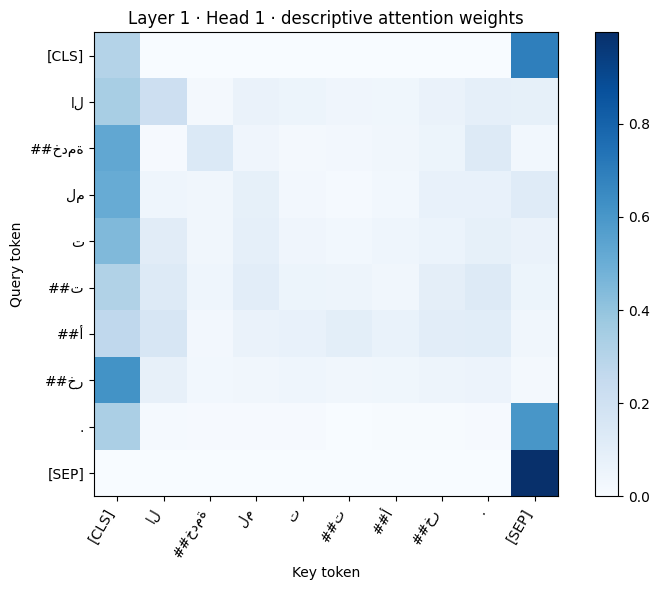

ACTUAL_TRANSFORMER_FORWARD=PASS


In [20]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
ACTUAL_MODEL_ID = "distilbert/distilbert-base-multilingual-cased"
actual_tokenizer = AutoTokenizer.from_pretrained(ACTUAL_MODEL_ID, use_fast=True)
actual_model = AutoModel.from_pretrained(ACTUAL_MODEL_ID, attn_implementation="eager")
actual_model.eval()

sentences = ["الخدمة لم تتأخر.", "The service was not delayed."]
encoded = actual_tokenizer(sentences, padding=True, truncation=True, max_length=32, return_tensors="pt")
with torch.no_grad():
    forward = actual_model(**encoded, output_attentions=True)

parameter_count = sum(parameter.numel() for parameter in actual_model.parameters())
attention_shape = tuple(forward.attentions[0].shape)
hidden_shape = tuple(forward.last_hidden_state.shape)
arabic_tokens = actual_tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
valid_length = int(encoded["attention_mask"][0].sum())
head_weights = forward.attentions[0][0, 0, :valid_length, :valid_length].cpu().numpy()

print(f"Model: {ACTUAL_MODEL_ID}")
print(f"Parameters: {parameter_count:,}")
print("Hidden-state shape:", hidden_shape)
print("Attention tensor [batch, heads, query, key]:", attention_shape)
print("Arabic tokens:", arabic_tokens[:valid_length])
print("Row-sum range:", float(head_weights.sum(-1).min()), float(head_weights.sum(-1).max()))

figure, axis = plt.subplots(figsize=(8, 6))
image = axis.imshow(head_weights, cmap="Blues", vmin=0.0)
axis.set_xticks(range(valid_length), arabic_tokens[:valid_length], rotation=60, ha="right")
axis.set_yticks(range(valid_length), arabic_tokens[:valid_length])
axis.set_xlabel("Key token")
axis.set_ylabel("Query token")
axis.set_title("Layer 1 · Head 1 · descriptive attention weights")
figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
plt.show()

assert parameter_count > 100_000_000
assert hidden_shape[:2] == tuple(encoded["input_ids"].shape)
assert attention_shape[0] == 2 and attention_shape[2] == attention_shape[3]
assert np.allclose(head_weights.sum(-1), 1.0, atol=1e-5)
print("ACTUAL_TRANSFORMER_FORWARD=PASS")

In [21]:
core_checks = {
    "weights_sum_to_one": np.allclose(weights.sum(axis=-1), 1.0),
    "two_checkpoint_parameter_audit": len(parameter_audits) == 2 and all(
        item["total_parameters"] == EXPECTED_TOTALS[item["model_id"]]
        for item in parameter_audits
    ),
    "actual_forward": parameter_count > 100_000_000 and len(forward.attentions) > 0,
    "output_shape": output.shape == (2, 2),
    "masked_positions_zero": masked_weights[0, 1] == 0 and masked_weights[0, 2] == 0,
    "heads_round_trip": np.allclose(combined, x),
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY1_NOTEBOOK2_CORE=PASS")

weights_sum_to_one: PASS
two_checkpoint_parameter_audit: PASS
actual_forward: PASS
output_shape: PASS
masked_positions_zero: PASS
heads_round_trip: PASS
DAY1_NOTEBOOK2_CORE=PASS
